# Sales performance: the numbers

This notebook is the source of truth for every number in the README and in the Power BI report.
It builds the same tables as Power Query (`powerbi/01-power-query.md`) with the same rules, computes each
number, draws the charts in `docs/`, and checks the main totals again with SQL (`sql/checks.sql`).

**Rules used everywhere**

- A sale is an item in an order that reached the customer (`order_status = delivered`).
- Revenue is the item price. Freight is shown on its own. There is no cost in the data, so no margin.
- An order is late when the delivery date is after the estimated date (dates only, times ignored).
- Each order keeps its latest review (the one answered last).
- Regions follow Brazil's five official regions.

Run it from the `analysis/` folder: `jupyter nbconvert --to notebook --execute --inplace analysis.ipynb`.

In [1]:
from pathlib import Path
import math

import duckdb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

RAW = Path("../data/raw")
DOCS = Path("../docs")
pd.set_option("display.float_format", "{:,.2f}".format)

## 1. Load the raw files

In [2]:
orders = pd.read_csv(
    RAW / "olist_orders_dataset.csv",
    parse_dates=["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"],
)
items = pd.read_csv(RAW / "olist_order_items_dataset.csv")
reviews = pd.read_csv(RAW / "olist_order_reviews_dataset.csv", parse_dates=["review_answer_timestamp"])
products = pd.read_csv(RAW / "olist_products_dataset.csv")
sellers = pd.read_csv(RAW / "olist_sellers_dataset.csv")
customers = pd.read_csv(RAW / "olist_customers_dataset.csv")
names = pd.read_csv(RAW / "product_category_name_translation.csv")

pd.Series({"orders": len(orders), "items": len(items), "reviews": len(reviews), "products": len(products),
           "sellers": len(sellers), "customers": len(customers)}, name="rows")

orders        99441
items        112650
reviews       99224
products      32951
sellers        3095
customers     99441
Name: rows, dtype: int64

## 2. Health check

Where this data can go wrong, and what the build does about it. The `assert` lines stop the notebook if a key
is not unique or a lookup has no match.

In [3]:
assert orders["order_id"].is_unique
assert products["product_id"].is_unique
assert sellers["seller_id"].is_unique
assert customers["customer_id"].is_unique
assert not items.duplicated(["order_id", "order_item_id"]).any()
assert items["order_id"].isin(orders["order_id"]).all()
assert items["product_id"].isin(products["product_id"]).all()
assert items["seller_id"].isin(sellers["seller_id"]).all()
assert orders["customer_id"].isin(customers["customer_id"]).all()

delivered = orders[orders["order_status"] == "delivered"]
with_two_reviews = reviews["order_id"].duplicated().sum()
answered_same_time = reviews.duplicated(["order_id", "review_answer_timestamp"]).sum()
assert answered_same_time == 0  # so "the latest review" is never a tie

pd.Series({
    "orders not delivered (left out)": len(orders) - len(delivered),
    "delivered orders with no items": (~delivered["order_id"].isin(items["order_id"])).sum(),
    "delivered orders with no delivery date (kept, not in late %)": delivered["order_delivered_customer_date"].isna().sum(),
    "extra reviews on the same order (latest kept)": with_two_reviews,
    "delivered orders with no review": (~delivered["order_id"].isin(reviews["order_id"])).sum(),
    "products with no category (shown as 'unknown')": products["product_category_name"].isna().sum(),
    "categories with no English name (Portuguese name kept)": len(set(products["product_category_name"].dropna()) - set(names["product_category_name"])),
}, name="count")

orders not delivered (left out)                                 2963
delivered orders with no items                                     0
delivered orders with no delivery date (kept, not in late %)       8
extra reviews on the same order (latest kept)                    551
delivered orders with no review                                  646
products with no category (shown as 'unknown')                   610
categories with no English name (Portuguese name kept)             2
Name: count, dtype: int64

In [4]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

## 3. Build the model tables

The same tables Power Query builds: one fact table at order-item grain and three dimensions. The date
dimension is built in DAX (`powerbi/02-model.md`).

In [5]:
REGIONS = {
    "North": ["AC", "AP", "AM", "PA", "RO", "RR", "TO"],
    "Northeast": ["AL", "BA", "CE", "MA", "PB", "PE", "PI", "RN", "SE"],
    "Center-West": ["DF", "GO", "MT", "MS"],
    "Southeast": ["ES", "MG", "RJ", "SP"],
    "South": ["PR", "RS", "SC"],
}
REGION_OF = {state: region for region, states in REGIONS.items() for state in states}

# Order level: dates only, delivery days and on time / late
o = delivered[["order_id", "customer_id"]].copy()
o["order_date"] = delivered["order_purchase_timestamp"].dt.normalize()
delivered_date = delivered["order_delivered_customer_date"].dt.normalize()
estimated_date = delivered["order_estimated_delivery_date"].dt.normalize()
o["delivery_days"] = (delivered_date - o["order_date"]).dt.days
o["delivery_status"] = "On time"
o.loc[delivered_date > estimated_date, "delivery_status"] = "Late"
o.loc[delivered_date.isna(), "delivery_status"] = "No date"

latest_review = (reviews.sort_values("review_answer_timestamp")
                 .drop_duplicates("order_id", keep="last")[["order_id", "review_score"]])

fact_sales = (items.merge(o, on="order_id")
              .merge(latest_review, on="order_id", how="left")
              [["order_id", "order_item_id", "order_date", "product_id", "seller_id", "customer_id",
                "price", "freight_value", "delivery_days", "delivery_status", "review_score"]])

dim_product = products.merge(names, on="product_category_name", how="left")
dim_product["category"] = (dim_product["product_category_name_english"]
                           .fillna(dim_product["product_category_name"])
                           .fillna("unknown")
                           .str.replace("_", " "))
dim_product = dim_product[["product_id", "category"]]

dim_seller = sellers[["seller_id", "seller_city", "seller_state"]].copy()
dim_seller["seller_region"] = dim_seller["seller_state"].map(REGION_OF)
dim_seller["seller_short_id"] = dim_seller["seller_id"].str[:8]

dim_customer = customers[["customer_id", "customer_unique_id", "customer_city", "customer_state"]].copy()
dim_customer["customer_region"] = dim_customer["customer_state"].map(REGION_OF)

assert dim_seller["seller_region"].notna().all() and dim_customer["customer_region"].notna().all()
assert not fact_sales.duplicated(["order_id", "order_item_id"]).any()

pd.Series({"fact_sales": len(fact_sales), "dim_product": len(dim_product), "dim_seller": len(dim_seller),
           "dim_customer": len(dim_customer)}, name="rows")

fact_sales      110197
dim_product      32951
dim_seller        3095
dim_customer     99441
Name: rows, dtype: int64

## 4. Headline numbers (Overview page)

Order-level numbers (delivery, reviews) are counted once per order, not once per item.

In [6]:
per_order = fact_sales.drop_duplicates("order_id").merge(dim_customer, on="customer_id")
dated = per_order[per_order["delivery_status"] != "No date"]

revenue = fact_sales["price"].sum()
freight = fact_sales["freight_value"].sum()
n_orders = fact_sales["order_id"].nunique()
n_customers = per_order["customer_unique_id"].nunique()
late_share = (dated["delivery_status"] == "Late").mean()

kpi = pd.Series({
    "Revenue": revenue,
    "Orders": n_orders,
    "Items sold": len(fact_sales),
    "Average order value": revenue / n_orders,
    "Customers": n_customers,
    "Freight": freight,
    "Freight % of revenue": freight / revenue * 100,
    "Late deliveries %": late_share * 100,
    "Late orders": (dated["delivery_status"] == "Late").sum(),
    "Average delivery days": dated["delivery_days"].mean(),
    "Average review": per_order["review_score"].mean(),
})
kpi

Revenue                 13,221,498.11
Orders                      96,478.00
Items sold                 110,197.00
Average order value            137.04
Customers                   93,358.00
Freight                  2,198,275.64
Freight % of revenue            16.63
Late deliveries %                6.77
Late orders                  6,534.00
Average delivery days           12.50
Average review                   4.16
dtype: float64

## 5. Growth against last year (Sales page)

The data stops on the last order date below, so 2018 is compared with the same days of 2017.

In [7]:
last_day = fact_sales["order_date"].max()
same_day_last_year = last_day - pd.DateOffset(years=1)
sales_2018 = fact_sales[fact_sales["order_date"].dt.year == 2018]
rev_2018 = sales_2018["price"].sum()
orders_2018 = sales_2018["order_id"].nunique()
rev_2017_same_days = fact_sales.loc[fact_sales["order_date"].between("2017-01-01", same_day_last_year), "price"].sum()
growth = rev_2018 / rev_2017_same_days - 1

orders_per_customer = per_order.groupby("customer_unique_id")["order_id"].nunique()
repeat_share = (orders_per_customer >= 2).mean()

pd.Series({
    "Last order date": last_day.date(),
    "Revenue 2018": rev_2018,
    "Revenue 2017, same days": rev_2017_same_days,
    "Growth %": growth * 100,
    "Orders 2018": orders_2018,
    "Average order value 2018": rev_2018 / orders_2018,
    "Freight % of revenue 2018": sales_2018["freight_value"].sum() / rev_2018 * 100,
    "Customers with 2+ orders %": repeat_share * 100,
}, dtype=object)

Last order date                2018-08-29
Revenue 2018                 7,218,125.12
Revenue 2017, same days      2,944,431.50
Growth %                           145.14
Orders 2018                         52783
Average order value 2018           136.75
Freight % of revenue 2018           17.09
Customers with 2+ orders %           3.00
dtype: object

In [8]:
monthly = (fact_sales.assign(month=fact_sales["order_date"].dt.to_period("M"))
           .groupby("month").agg(revenue=("price", "sum"), orders=("order_id", "nunique")))
monthly["average_order_value"] = monthly["revenue"] / monthly["orders"]
monthly.loc["2017-01":]

,revenue,orders,average_order_value
month,,,
2017-01,"111,798.36",750,149.06
2017-02,"234,223.40",1653,141.70
2017-03,"359,198.85",2546,141.08
2017-04,"340,669.68",2303,147.92
2017-05,"489,338.25",3546,138.00
2017-06,"421,923.37",3135,134.58
2017-07,"481,604.52",3872,124.38
2017-08,"554,699.70",4193,132.29
2017-09,"607,399.67",4150,146.36


## 6. Delivery and reviews (Delivery page)

In [9]:
by_status = (per_order[per_order["delivery_status"] != "No date"]
             .groupby("delivery_status")
             .agg(orders=("order_id", "count"),
                  average_review=("review_score", "mean"),
                  one_or_two_stars_pct=("review_score", lambda s: (s <= 2).sum() / s.notna().sum() * 100),
                  average_delivery_days=("delivery_days", "mean")))
by_status

,orders,average_review,one_or_two_stars_pct,average_delivery_days
delivery_status,,,,
Late,6534,2.27,62.42,33.91
On time,89936,4.29,9.27,10.94


In [10]:
late_by_state = (dated.groupby("customer_state")
                 .agg(orders=("order_id", "count"), late_pct=("delivery_status", lambda s: (s == "Late").mean() * 100))
                 .sort_values("late_pct", ascending=False))
late_by_state.head(5)

,orders,late_pct
customer_state,,
AL,397,21.41
MA,717,17.43
SE,335,15.22
PI,476,13.87
CE,1279,13.76


## 7. Categories (Categories page)

In [11]:
by_category = (fact_sales.merge(dim_product, on="product_id")
               .groupby("category")
               .agg(revenue=("price", "sum"), items=("order_item_id", "count"))
               .sort_values("revenue", ascending=False))
by_category["share_pct"] = by_category["revenue"] / revenue * 100
top10_category_share = by_category["revenue"].head(10).sum() / revenue

print(f"Categories with sales: {len(by_category)}")
print(f"Top 10 categories: {top10_category_share:.1%} of revenue")
by_category.head(10)

Categories with sales: 74
Top 10 categories: 62.4% of revenue


,revenue,items,share_pct
category,,,
health beauty,"1,233,131.72",9465,9.33
watches gifts,"1,166,176.98",5859,8.82
bed bath table,"1,023,434.76",10953,7.74
sports leisure,"954,852.55",8431,7.22
computers accessories,"888,724.61",7644,6.72
furniture decor,"711,927.69",8160,5.38
housewares,"615,628.69",6795,4.66
cool stuff,"610,204.10",3718,4.62
auto,"578,966.65",4140,4.38


## 8. Sellers (Sellers page)

The top 10% of sellers is the first `ceil(sellers with sales / 10)` sellers by revenue, the same rule as the DAX
measure `Top 10% Sellers Share`.

In [12]:
by_seller = (fact_sales.groupby("seller_id")["price"].sum().sort_values(ascending=False))
n_sellers = len(by_seller)
n_top = math.ceil(n_sellers / 10)
top10_seller_share = by_seller.head(n_top).sum() / revenue

print(f"Sellers with sales: {n_sellers}; top 10% = {n_top} sellers")
print(f"Top 10% of sellers: {top10_seller_share:.1%} of revenue")
top_seller = by_seller.index[0]
print(f"Largest seller: {top_seller[:8]} with {by_seller.iloc[0]:,.2f}")

Sellers with sales: 2970; top 10% = 297 sellers
Top 10% of sellers: 67.1% of revenue
Largest seller: 4869f7a5 with 226,987.93


## 9. Regions (row-level security check)

Each security role shows only one seller region. These are the revenue totals each role must see.

In [13]:
by_seller_region = (fact_sales.merge(dim_seller, on="seller_id")
                    .groupby("seller_region")["price"].sum().sort_values(ascending=False))
by_customer_region = (fact_sales.merge(dim_customer, on="customer_id")
                      .groupby("customer_region")["price"].sum().sort_values(ascending=False))
pd.DataFrame({"revenue by seller region": by_seller_region, "revenue by customer region": by_customer_region})

,revenue by seller region,revenue by customer region
Southeast,"10,354,931.00","8,648,409.57"
South,"2,219,100.72","1,901,973.11"
Northeast,"455,082.78","1,497,083.78"
Center-West,"185,206.41","846,956.70"
North,"7,177.20","327,074.95"


## 10. Charts for the README

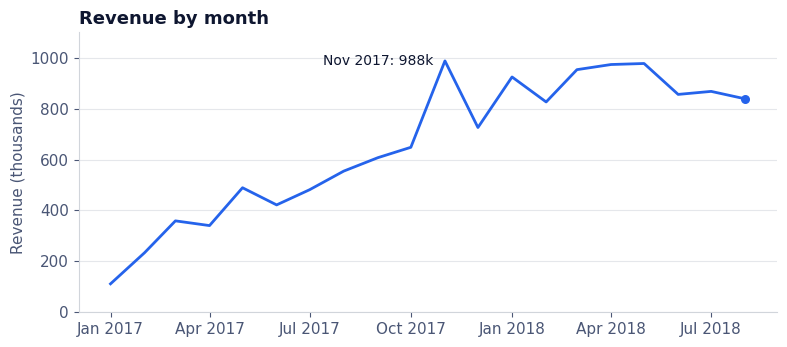

In [14]:
NAVY, BLUE, ORANGE, GREY = "#0E1630", "#2563EB", "#C2410C", "#4A5675"
plt.rcParams.update({
    "font.size": 11, "text.color": NAVY, "axes.labelcolor": GREY, "xtick.color": GREY, "ytick.color": GREY,
    "axes.edgecolor": "#D1D5DB", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E5E7EB", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "figure.facecolor": "white", "savefig.facecolor": "white", "savefig.dpi": 150,
})

# Revenue by month, Jan 2017 to Aug 2018
m = monthly.loc["2017-01":]
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(m.index.to_timestamp(), m["revenue"] / 1e3, color=BLUE, linewidth=2)
ax.scatter(m.index[-1].to_timestamp(), m["revenue"].iloc[-1] / 1e3, color=BLUE, s=30, zorder=3)
peak = m["revenue"].idxmax()
ax.annotate(f"{peak.strftime('%b %Y')}: {m['revenue'].max() / 1e3:,.0f}k", (peak.to_timestamp(), m["revenue"].max() / 1e3),
            xytext=(-8, 0), textcoords="offset points", ha="right", va="center", fontsize=10)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_ylabel("Revenue (thousands)")
ax.set_ylim(0, 1100)
ax.grid(axis="x", visible=False)
ax.set_title("Revenue by month", loc="left", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(DOCS / "revenue-by-month.png")
plt.show()

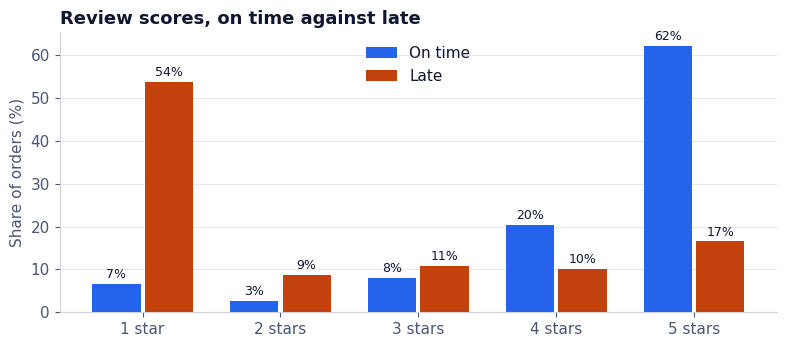

In [15]:
# Review scores: on time against late (share of reviewed orders at each score)
reviewed = per_order[per_order["review_score"].notna() & (per_order["delivery_status"] != "No date")]
dist = (pd.crosstab(reviewed["review_score"].astype(int), reviewed["delivery_status"], normalize="columns") * 100)[["On time", "Late"]]

fig, ax = plt.subplots(figsize=(8, 3.6))
width = 0.38
for offset, status, color in [(-width / 2, "On time", BLUE), (width / 2, "Late", ORANGE)]:
    bars = ax.bar(dist.index + offset, dist[status], width=width - 0.03, color=color, label=status)
    ax.bar_label(bars, fmt="%.0f%%", fontsize=9, color=NAVY, padding=2)
ax.set_xticks(dist.index, [f"{s} star" + ("s" if s > 1 else "") for s in dist.index])
ax.set_ylabel("Share of orders (%)")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, loc="upper center")
ax.set_title("Review scores, on time against late", loc="left", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(DOCS / "reviews-on-time-vs-late.png")
plt.show()

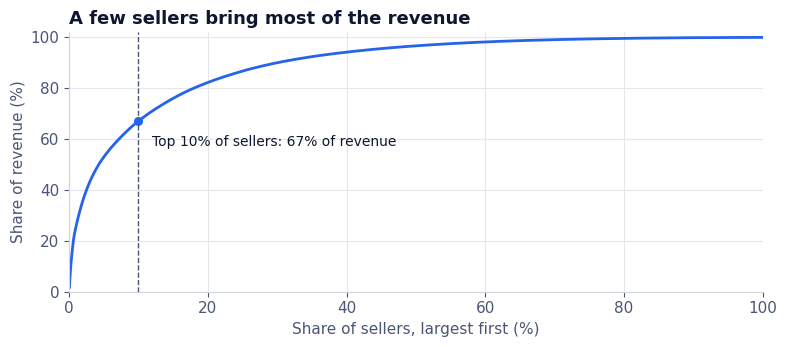

In [16]:
# Seller concentration: cumulative share of revenue against share of sellers
cum = by_seller.cumsum() / revenue * 100
x = pd.Series(range(1, n_sellers + 1)) / n_sellers * 100

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(x, cum.values, color=BLUE, linewidth=2)
ax.axvline(10, color=GREY, linewidth=1, linestyle="--")
ax.scatter([n_top / n_sellers * 100], [top10_seller_share * 100], color=BLUE, s=30, zorder=3)
ax.annotate(f"Top 10% of sellers: {top10_seller_share:.0%} of revenue", (n_top / n_sellers * 100, top10_seller_share * 100),
            xytext=(10, -18), textcoords="offset points", fontsize=10)
ax.set_xlabel("Share of sellers, largest first (%)")
ax.set_ylabel("Share of revenue (%)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 102)
ax.set_title("A few sellers bring most of the revenue", loc="left", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(DOCS / "seller-concentration.png")
plt.show()

## 11. Check the totals again with SQL

`sql/checks.sql` computes the main totals straight from the raw files with DuckDB, without pandas. Every value
must match the notebook.

In [17]:
con = duckdb.connect()
con.execute("SET file_search_path = '..'")  # the SQL file uses paths from the repo root
sql = con.sql((Path("..") / "sql" / "checks.sql").read_text()).df().iloc[0]

pairs = {
    "revenue": revenue,
    "orders": n_orders,
    "customers": n_customers,
    "late_pct": late_share * 100,
    "avg_review": kpi["Average review"],
    "growth_pct": growth * 100,
}
check = pd.DataFrame({"notebook": pairs, "sql": {k: sql[k] for k in pairs}})
check["match"] = [math.isclose(a, b, rel_tol=1e-9) for a, b in zip(check["notebook"], check["sql"])]
assert check["match"].all(), check
check

,notebook,sql,match
revenue,"13,221,498.11","13,221,498.11",True
orders,"96,478.00","96,478.00",True
customers,"93,358.00","93,358.00",True
late_pct,6.77,6.77,True
avg_review,4.16,4.16,True
growth_pct,145.14,145.14,True


## 12. Numbers for `powerbi/06-checks.md` and the README

In [18]:
summary = pd.Series({
    "Revenue": f"{revenue:,.2f}",
    "Orders": f"{n_orders:,}",
    "Items sold": f"{len(fact_sales):,}",
    "Average order value": f"{revenue / n_orders:,.2f}",
    "Customers": f"{n_customers:,}",
    "Freight % of revenue": f"{freight / revenue:.1%}",
    "Late deliveries %": f"{late_share:.1%}",
    "Late orders": f"{kpi['Late orders']:,.0f}",
    "Average delivery days": f"{kpi['Average delivery days']:.1f}",
    "Average review": f"{kpi['Average review']:.2f}",
    "Average review, on time": f"{by_status.loc['On time', 'average_review']:.2f}",
    "Average review, late": f"{by_status.loc['Late', 'average_review']:.2f}",
    "1-2 stars, on time": f"{by_status.loc['On time', 'one_or_two_stars_pct']:.1f}%",
    "1-2 stars, late": f"{by_status.loc['Late', 'one_or_two_stars_pct']:.1f}%",
    "1 star, on time": f"{dist.loc[1, 'On time']:.1f}%",
    "1 star, late": f"{dist.loc[1, 'Late']:.1f}%",
    "Highest late % state": f"{late_by_state.index[0]} ({late_by_state['late_pct'].iloc[0]:.1f}%)",
    "Customers with 2+ orders %": f"{repeat_share:.1%}",
    "2018: revenue": f"{rev_2018:,.2f}",
    "2018: revenue last year (same days of 2017)": f"{rev_2017_same_days:,.2f}",
    "2018: revenue vs last year %": f"{growth:.1%}",
    "2018: orders": f"{orders_2018:,}",
    "2018: average order value": f"{rev_2018 / orders_2018:,.2f}",
    "2018: freight % of revenue": f"{sales_2018['freight_value'].sum() / rev_2018:.1%}",
    "Categories with sales": f"{len(by_category)}",
    "Top category": f"{by_category.index[0]} ({by_category['revenue'].iloc[0]:,.2f})",
    "Top 10 categories share": f"{top10_category_share:.1%}",
    "Sellers with sales": f"{n_sellers:,}",
    "Top 10% sellers share": f"{top10_seller_share:.1%}",
    "Largest seller": f"{top_seller[:8]} ({by_seller.iloc[0]:,.2f})",
    **{f"Role {r}: revenue": f"{v:,.2f}" for r, v in by_seller_region.items()},
}, name="value")
summary

Revenue                                                       13,221,498.11
Orders                                                               96,478
Items sold                                                          110,197
Average order value                                                  137.04
Customers                                                            93,358
Freight % of revenue                                                  16.6%
Late deliveries %                                                      6.8%
Late orders                                                           6,534
Average delivery days                                                  12.5
Average review                                                         4.16
Average review, on time                                                4.29
Average review, late                                                   2.27
1-2 stars, on time                                                     9.3%
1-2 stars, l